# AccessScan — Sprint 2: Detection Model Training
**La Trobe University × DITRDCA**

Run each cell top to bottom in order.

## Cell 1 — Check GPU

In [1]:
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('No GPU found — training will use CPU (slower)')

CUDA available: True
GPU: NVIDIA GeForce GTX 1060 with Max-Q Design
VRAM: 6.44 GB


## Cell 2 — Train YOLOv8

In [2]:
from ultralytics import YOLO

# Load YOLOv8 small model pretrained on COCO
model = YOLO('yolov8s.pt')

# Train on AccessScan dataset
results = model.train(
    data='AccessScan-DSAPT/data.yaml',  # path to exported Roboflow dataset
    epochs=50,
    imgsz=640,
    batch=16,           # reduce to 8 if you get memory error
    name='accessscan-v1',
    patience=10,        # stops early if no improvement for 10 epochs
    device=0            # use GPU (GTX 1060)
)

print('Training done. Model saved to runs/detect/accessscan-v1/')

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\sumit\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.49  Python-3.11.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1060 with Max-Q Design, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=AccessScan-DSAPT/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0

## Cell 3 — View Training Results

=== Training Metrics ===


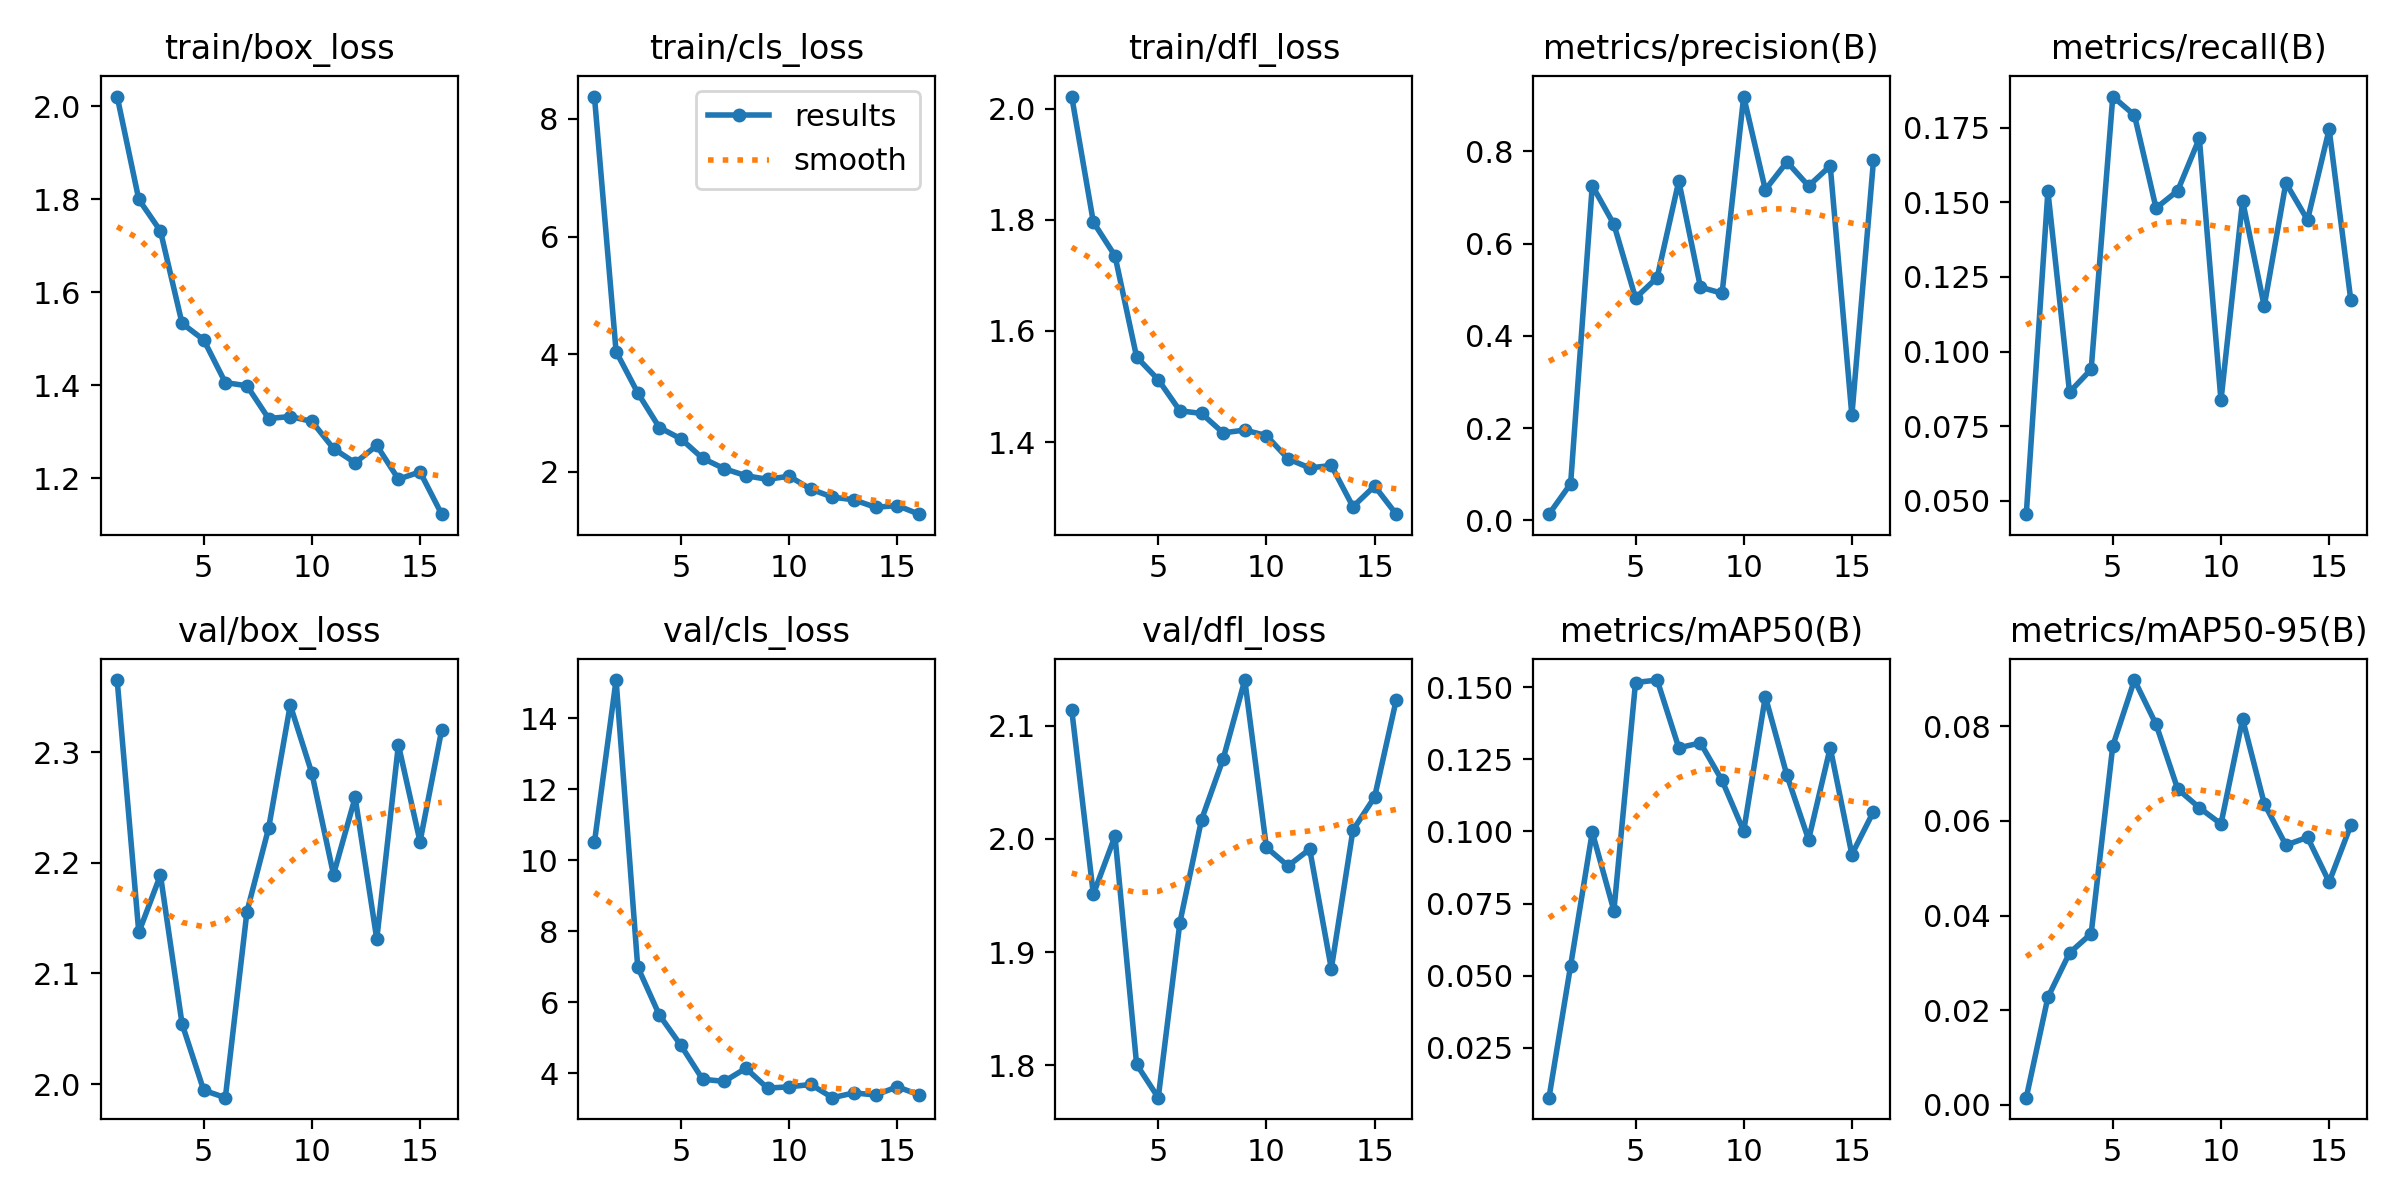

=== Confusion Matrix ===


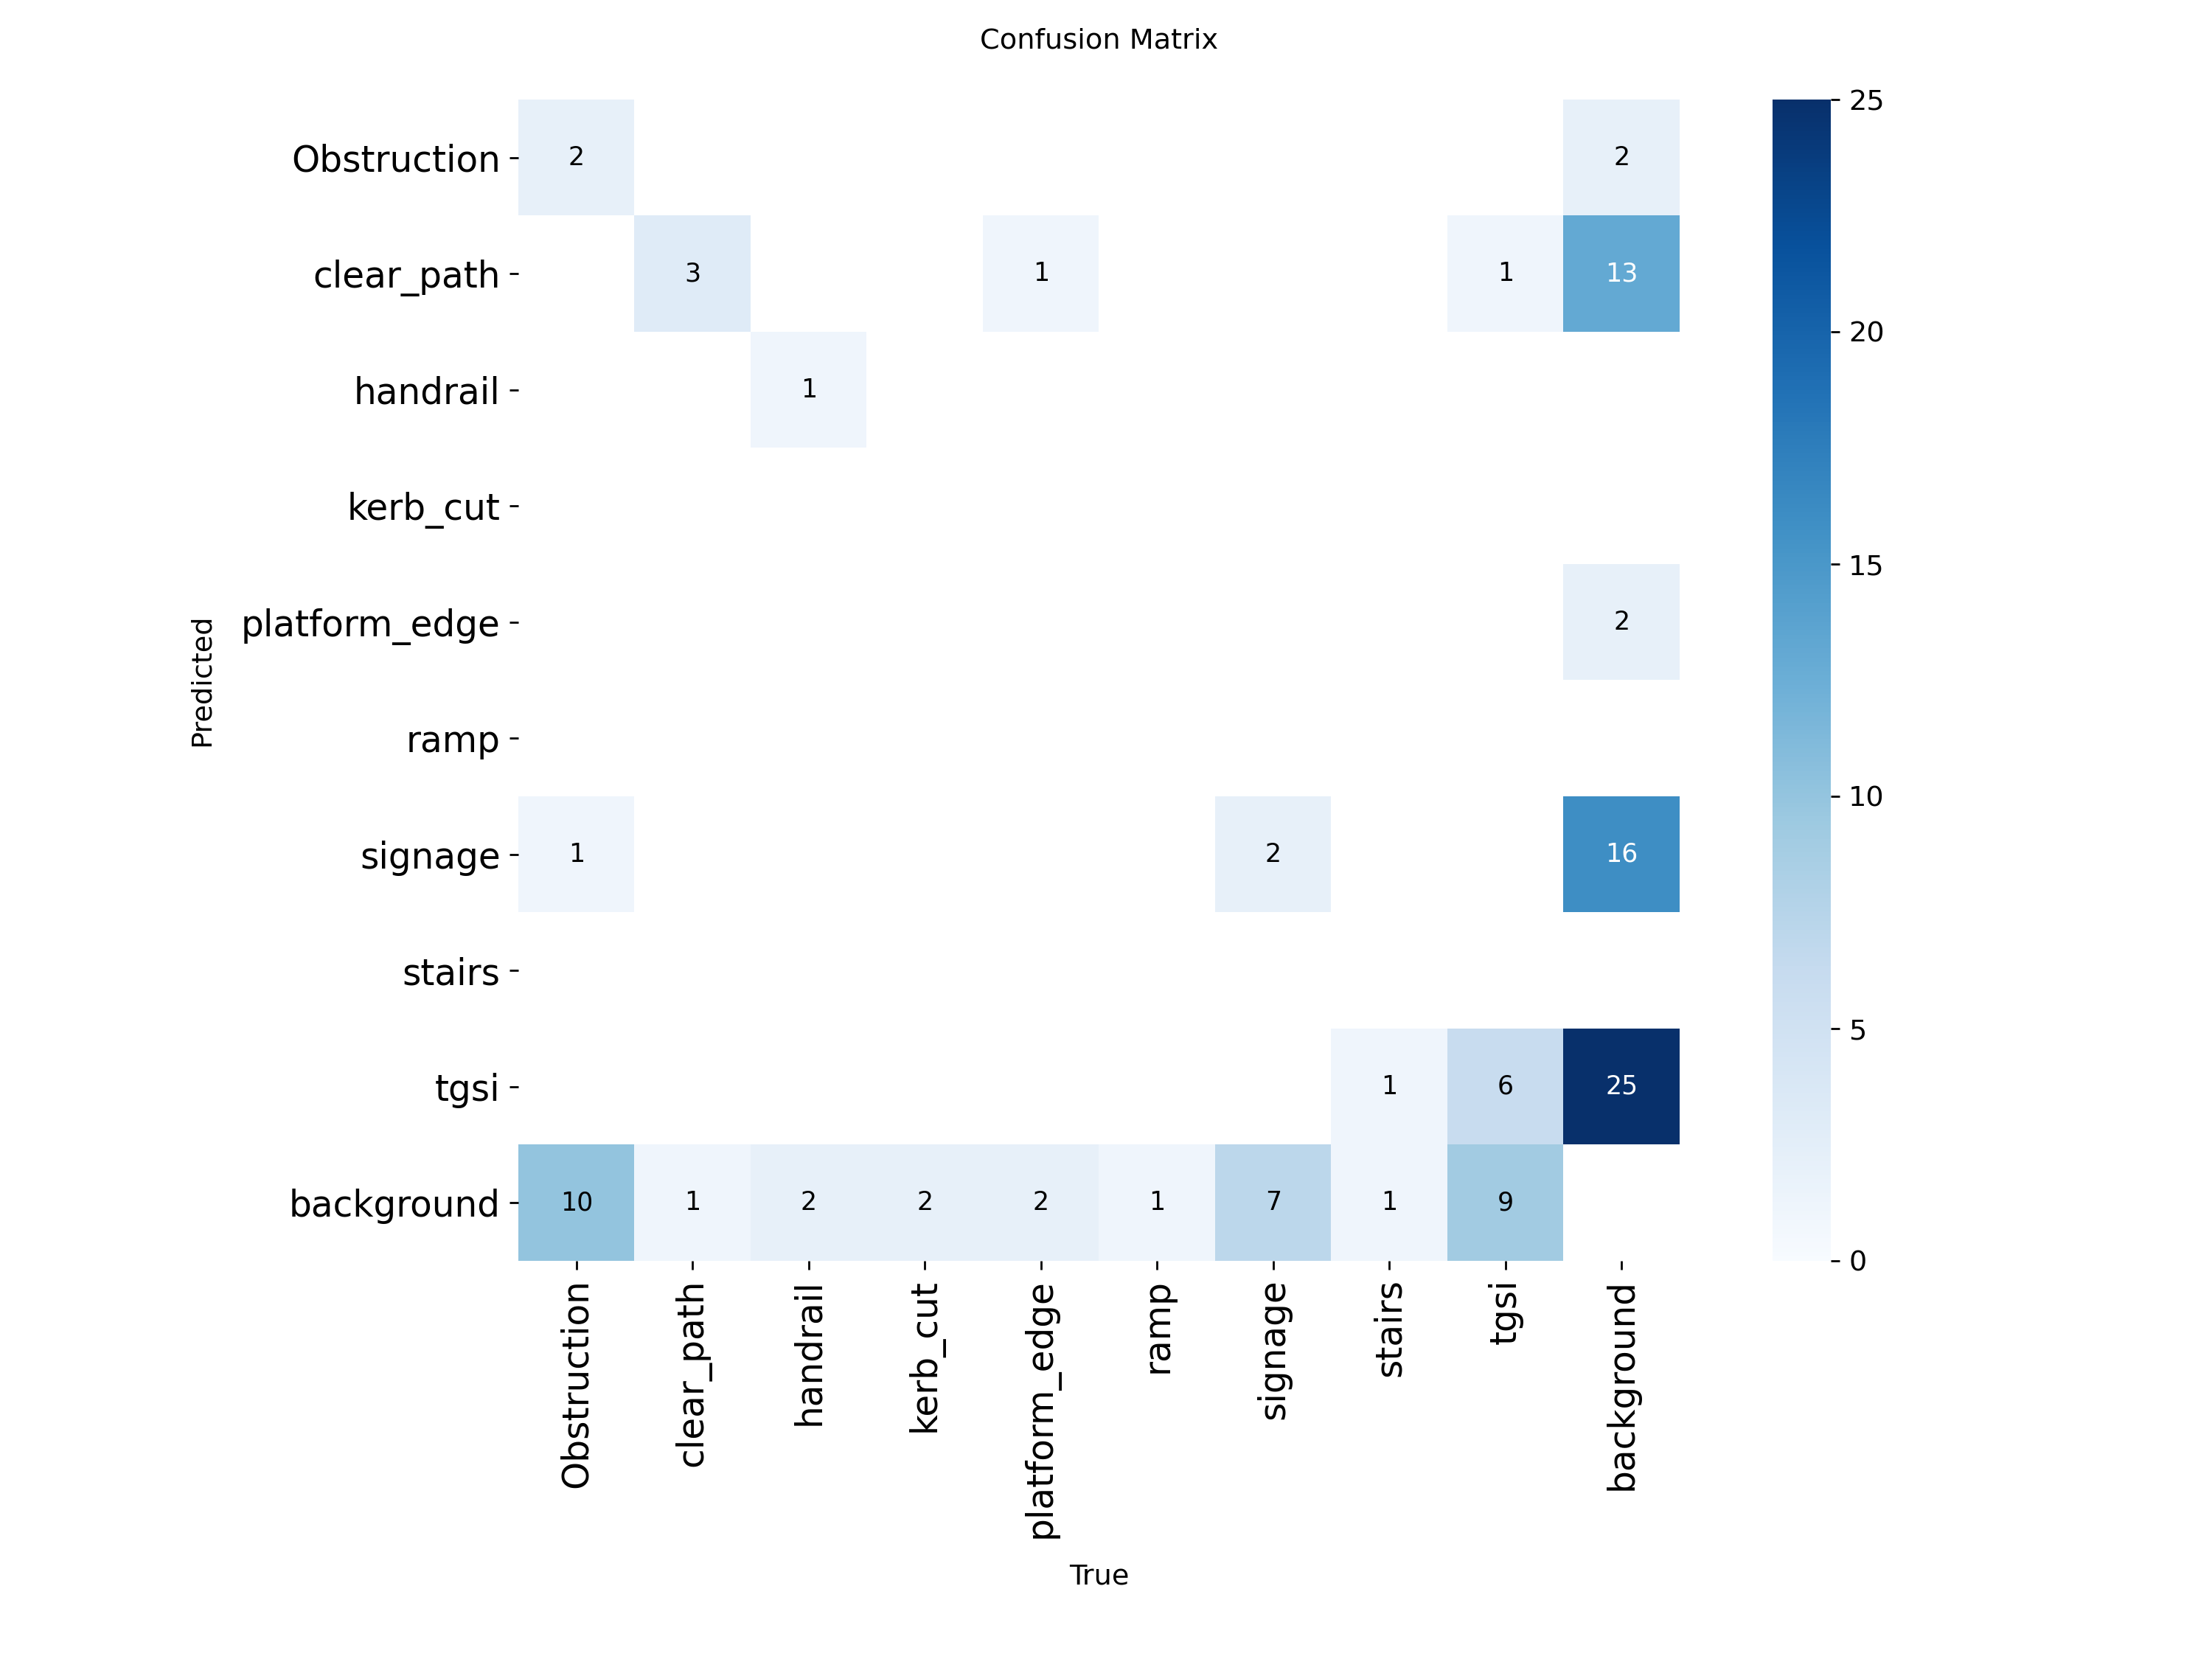

In [3]:
from IPython.display import Image, display

# mAP and loss curves
print('=== Training Metrics ===')
display(Image('runs/detect/accessscan-v1/results.png'))

# Confusion matrix
print('=== Confusion Matrix ===')
display(Image('runs/detect/accessscan-v1/confusion_matrix.png'))

## Cell 4 — MiDaS Depth Estimation

In [5]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load MiDaS small model
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small')
midas.eval()
transform = torch.hub.load('intel-isl/MiDaS', 'transforms').small_transform

def estimate_depth(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img_rgb)
    with torch.no_grad():
        depth = midas(input_tensor)
    return depth.squeeze().numpy()

# Run on ramp photo
depth = estimate_depth('ramp_photo.jpeg')
print('Depth range:', round(float(depth.min()), 2), 'to', round(float(depth.max()), 2))

# Visualise depth map
plt.figure(figsize=(10, 6))
plt.imshow(depth, cmap='plasma')
plt.colorbar(label='Relative Depth')
plt.title('MiDaS Depth Map — ramp_photo.jpeg')
plt.axis('off')
plt.show()

Using cache found in C:\Users\sumit/.cache\torch\hub\intel-isl_MiDaS_master
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:  None


c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to C:\Users\sumit/.cache\torch\hub\master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to C:\Users\sumit/.cache\torch\hub\checkpoints\tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to C:\Users\sumit/.cache\torch\hub\checkpoints\midas_v21_small_256.pt


100.0%
Using cache found in C:\Users\sumit/.cache\torch\hub\intel-isl_MiDaS_master


Depth range: 0.0 to 973.67


<Figure size 1000x600 with 2 Axes>

## Cell 5 — Inference on Test Image

In [6]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# Load trained model
model = YOLO('runs/detect/accessscan-v1/weights/best.pt')

# Run inference on ramp photo
results = model('ramp_photo.jpeg', save=True, project='runs/inference', name='test1')

# Print detections
print('=== Detections ===')
for box in results[0].boxes:
    cls = results[0].names[int(box.cls)]
    conf = float(box.conf)
    print(f'Detected: {cls:<20} confidence: {conf:.2f}')

# Show annotated image inline
annotated_path = 'runs/inference/test1/ramp_photo.jpeg'
if os.path.exists(annotated_path):
    display(Image(annotated_path))
else:
    print('Annotated image saved to runs/inference/test1/')


image 1/1 d:\projects\Project_AccessScan_DSAPT\ramp_photo.jpeg: 640x480 2 Obstructions, 1 clear_path, 2 handrails, 1 platform_edge, 3 signages, 5 tgsis, 44.4ms
Speed: 3.0ms preprocess, 44.4ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to D:\projects\Project_AccessScan_DSAPT\runs\detect\runs\inference\test1
=== Detections ===
Detected: handrail             confidence: 0.87
Detected: signage              confidence: 0.86
Detected: tgsi                 confidence: 0.84
Detected: signage              confidence: 0.53
Detected: handrail             confidence: 0.44
Detected: tgsi                 confidence: 0.40
Detected: tgsi                 confidence: 0.39
Detected: clear_path           confidence: 0.36
Detected: platform_edge        confidence: 0.30
Detected: tgsi                 confidence: 0.30
Detected: Obstruction          confidence: 0.27
Detected: tgsi                 confidence: 0.27
Detected: Obstruction          confidence: 0.27
Detected: si